In [1]:
import pandas as pd

In [3]:
data=pd.read_excel("Employees.xlsx")

In [5]:
data.head()

,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Sick Leaves,Unpaid Leaves,Overtime Hours
0,1,Ghadir,Hmshw,Male,2018-04-04,2,Quality Control,Egypt,West,1560,18720,3.0,1,0,183
1,2,Omar,Hishan,Male,2020-05-21,0,Quality Control,Saudi Arabia,West,3247,38964,1.0,0,5,198
2,3,Ailya,Sharaf,Female,2017-09-28,3,Major Mfg Projects,Saudi Arabia,West,2506,30072,2.0,0,3,192
3,4,Lwiy,Qbany,Male,2018-08-14,2,Manufacturing,United Arab Emirates,Main,1828,21936,3.0,0,0,7
4,5,Ahmad,Bikri,Male,2020-03-11,0,Manufacturing,Egypt,Main,970,11640,5.0,0,5,121


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   No              689 non-null    int64         
 1   First Name      689 non-null    object        
 2   Last Name       689 non-null    object        
 3   Gender          689 non-null    object        
 4   Start Date      689 non-null    datetime64[ns]
 5   Years           689 non-null    int64         
 6   Department      689 non-null    object        
 7   Country         689 non-null    object        
 8   Center          689 non-null    object        
 9   Monthly Salary  689 non-null    int64         
 10  Annual Salary   689 non-null    int64         
 11  Job Rate        689 non-null    float64       
 12  Sick Leaves     689 non-null    int64         
 13  Unpaid Leaves   689 non-null    int64         
 14  Overtime Hours  689 non-null    int64         
dtypes: dat

In [7]:
data.shape

(689, 15)

In [9]:
data.isna().sum()

No                0
First Name        0
Last Name         0
Gender            0
Start Date        0
Years             0
Department        0
Country           0
Center            0
Monthly Salary    0
Annual Salary     0
Job Rate          0
Sick Leaves       0
Unpaid Leaves     0
Overtime Hours    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [14]:
import matplotlib.pyplot as plt

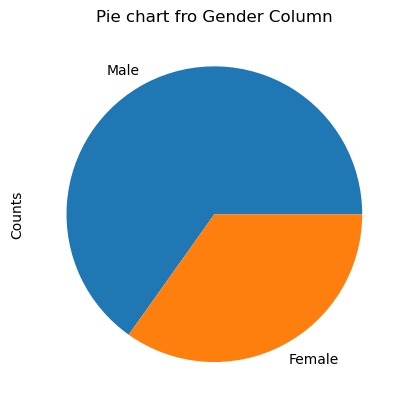

In [22]:
data["Gender"].value_counts().sort_values(ascending=False).plot(kind="pie")
plt.title("Pie chart fro Gender Column")
plt.ylabel("Counts")
plt.show()

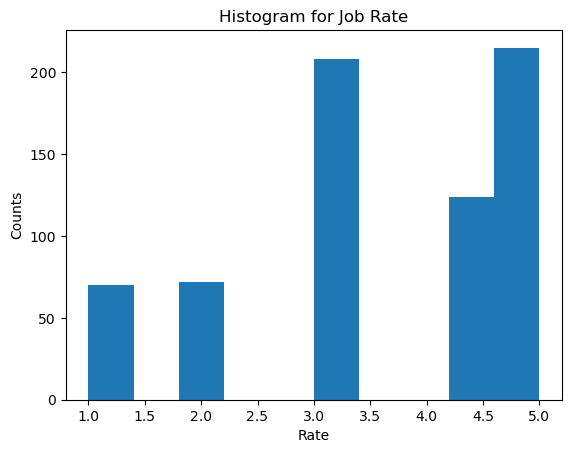

In [24]:
plt.hist(data["Job Rate"])
plt.title("Histogram for Job Rate")
plt.xlabel("Rate")
plt.ylabel("Counts")
plt.show()

In [26]:
data["Job Rate"].describe()

count    689.000000
mean       3.586357
std        1.350125
min        1.000000
25%        3.000000
50%        3.000000
75%        5.000000
max        5.000000
Name: Job Rate, dtype: float64

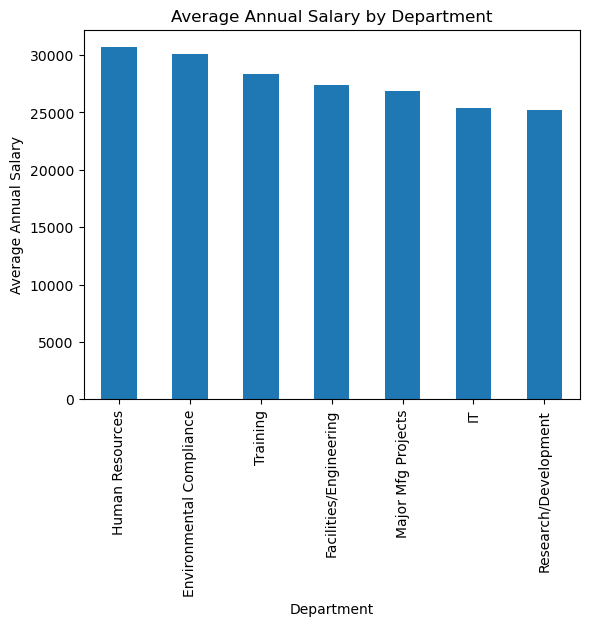

In [34]:
data.groupby("Department")["Annual Salary"].mean().sort_values(ascending=False).head(7).plot(kind="bar")
plt.title("Average Annual Salary by Department")
plt.xlabel("Department")    
plt.ylabel("Average Annual Salary")
plt.show()

In [37]:
data.groupby("Center")["Monthly Salary"].mean().sort_values(ascending=False)

Center
East     2274.021277
West     2068.672269
North    2064.811594
Main     2054.776892
South    1981.153846
Name: Monthly Salary, dtype: float64

In [38]:
data["Country"].unique

<bound method Series.unique of 0                     Egypt
1              Saudi Arabia
2              Saudi Arabia
3      United Arab Emirates
4                     Egypt
               ...         
684                 Lebanon
685                   Egypt
686                   Egypt
687                   Egypt
688    United Arab Emirates
Name: Country, Length: 689, dtype: object>

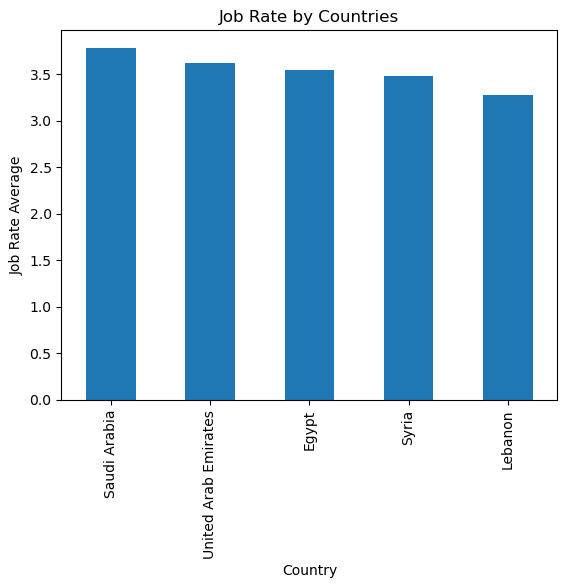

In [40]:
data.groupby("Country")["Job Rate"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Job Rate by Countries")
plt.xlabel("Country")
plt.ylabel("Job Rate Average")
plt.show()

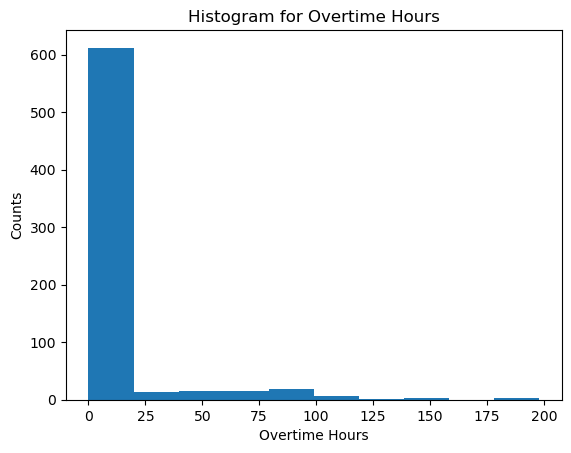

In [42]:
plt.hist(data["Overtime Hours"])
plt.title("Histogram for Overtime Hours")
plt.xlabel("Overtime Hours")
plt.ylabel("Counts")
plt.show()

In [43]:
data["Overtime Hours"].describe()

count    689.000000
mean      13.702467
std       25.692049
min        0.000000
25%        3.000000
50%        7.000000
75%       10.000000
max      198.000000
Name: Overtime Hours, dtype: float64

In [44]:
data["Annual Salary"].describe()

count      689.000000
mean     24818.420900
std       9159.470878
min       8436.000000
25%      17232.000000
50%      24924.000000
75%      32184.000000
max      41400.000000
Name: Annual Salary, dtype: float64

In [46]:
x=data[["Years", "Job Rate"]]
y=data["Annual Salary"]

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

In [49]:
len(x_train)

551

In [50]:
len(y_test)

138

In [52]:
from sklearn.linear_model import LinearRegression

In [53]:
lr=LinearRegression()

In [54]:
lr.fit(x_train,y_train)

LinearRegression()

In [56]:
pred=lr.predict(x_test)

In [58]:
from sklearn.metrics import mean_absolute_error

In [60]:
mean_absolute_error(pred,y_test)

7258.644818589788

In [61]:
import joblib
joblib.dump(lr,"model.joblib")

['model.joblib']